In [1]:
# CUDA_VISIBLE_DEVICES=""

In [2]:
import torch
import clip
from PIL import Image
import cv2
from matplotlib import pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.image as mpimg
import re
from itertools import chain
import nltk
# nltk.download("wordnet")
# nltk.download("omw-1.4")
from nltk.corpus import wordnet as wn


In [3]:
synsets = wn.synsets("dog", pos=wn.NOUN)
print(synsets)


[Synset('dog.n.01'), Synset('frump.n.01'), Synset('dog.n.03'), Synset('cad.n.01'), Synset('frank.n.02'), Synset('pawl.n.01'), Synset('andiron.n.01')]


In [4]:
import ipynb
import sys
import importlib
sys.path.append('.')
import dictionary_container as dc
# importlib.reload(dictionary_container)

# dc.show_img_dial_descriptions(50, dc.dict_dial_img_description)

In [5]:
device = torch.device('cuda:3')

In [6]:
# model, preprocess = clip.load("ViT-B/32", device=device)
# image = preprocess(Image.open("PhotoBook/images/bus_truck/COCO_train2014_000000253054.jpg")).unsqueeze(0).to(device)
# text = clip.tokenize(["a diagram", "a dog", "a cat"]).to(device)

# with torch.no_grad():
#     image_features = model.encode_image(image)
#     text_features = model.encode_text(text)
    
#     logits_per_image, logits_per_text = model(image, text)
#     probs = logits_per_image.softmax(dim=-1).cpu().numpy()

# print("Label probs:", probs)  # prints: [[0.9927937  0.00421068 0.00299572]]

In [7]:
clip.available_models()
# clip.tokenize(text: Union[str, List[str]], context_length=77)

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [8]:
ViT32, preprocess = clip.load('ViT-B/32', device=device, jit=False)

In [9]:
type(preprocess)

torchvision.transforms.transforms.Compose

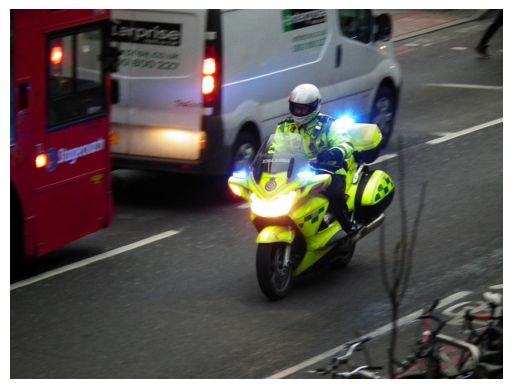

In [10]:
file_cv = cv2.imread("PhotoBook/images/bus_truck/COCO_train2014_000000253054.jpg")
file_cv = file_cv[:, :, [2,1,0]]  

plt.imshow(file_cv)
plt.axis("off")
plt.show()


In [11]:
# from torchvision.datasets import CIFAR100
# import os
# cifar100 = CIFAR100(root=os.path.expanduser("~/.cache"), download=True, train=False)

In [12]:
# image, class_id = cifar100[3637]
# type(image)

In [13]:
file_PIL = Image.open('PhotoBook/images/bus_truck/COCO_train2014_000000253054.jpg')
transform_PIL = transforms.Compose([transforms.PILToTensor()])
# tensor_PIL = transform_PIL(file_PIL).to(device)

# plt.imshow(file_PIL)
# plt.axis("off")
# plt.show()

In [14]:
# t = torch.from_numpy(file_cv)
# t = t.permute(2, 0, 1).to(device)
tensor_PIL = preprocess(file_PIL).unsqueeze(0).to(device)

In [15]:
outcome = ViT32.encode_image(tensor_PIL)

In [16]:
type(outcome)

torch.Tensor

In [17]:
list_paths = list(dc.dict_dial_img_description.keys())

In [18]:
def paths2tensors(ds_list):
    new_list = []
    for path in ds_list:
        file_PIL = Image.open("PhotoBook/images/" + path)
        tensor_PIL = preprocess(file_PIL)
        new_list.append(tensor_PIL)
        
    return torch.stack(new_list).to(device)
list_tnsrs_imgs = paths2tensors(list_paths)

In [19]:
# descriptions_base = ["car", "human", "animal", "snow", "art"]
# descriptions_base_tkn = clip.tokenize(descriptions_base).to(device)

with open('ms_coco_classnames.txt') as file:
    readable = file.read()
    splited = readable.split("\n")

    list_classes_coco = []
    for i, line in enumerate(splited):
        if i>0:
            match = re.search(r"'([^']*)'", line)
            if match:
                result = match.group(1)
                list_classes_coco.append(result)
list_classes_coco = list_classes_coco + ["man", "woman", "girl", "boy", "human", "soldier", "army"]
list_classes_coco_tnsr = clip.tokenize(list_classes_coco).to(device)


In [20]:
indx2lbl_coco = {x:list_classes_coco[x] for x in range(len(list_classes_coco))}

In [21]:
with torch.no_grad():
    # image_features = ViT32.encode_image(image)
    # text_features = ViT32.encode_text(text)
    
    logits_per_image, logits_per_text = ViT32(list_tnsrs_imgs, list_classes_coco_tnsr)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    
# print("Label probs:", probs)  # prints: [[0.9927937  0.00421068 0.00299572]]


In [27]:
with torch.no_grad():
    image_features = ViT32.encode_image(list_tnsrs_imgs)
    print(image_features)

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 3 has a total capacity of 10.90 GiB of which 11.25 MiB is free. Process 705905 has 2.76 GiB memory in use. Including non-PyTorch memory, this process has 8.13 GiB memory in use. Of the allocated memory 7.80 GiB is allocated by PyTorch, and 180.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [22]:
# this function is wrong, rn it only accepts integers as "title argument"
def compare_dial_clip(title, main_dict, i2l, probs_v):
    list_of_keys = list(main_dict.keys())
    if isinstance(title, int):
        title_string = list_of_keys[title]
    print("Human Dialogue:")
    for i, descr in enumerate(main_dict[title_string]):
        print(i, "-", descr)

    photo = mpimg.imread("PhotoBook/images/" + title_string)

    unordered_list = []
    for i, value in enumerate(probs_v[title]):
        label = i2l[i]
        unordered_list.append((label, float(value)))
    sorted_list = sorted(unordered_list, key=lambda tpl: tpl[1], reverse=True)

    print("\nClip Object Detection:")
    for tpl in sorted_list[:5]:
        print(round(tpl[1], 4), "-", tpl[0])

    plt.imshow(photo)
    plt.axis("off")

Human Dialogue:
0 - Stick the guy holding two elephants?
1 - White shirt in front of elephant walking?
2 - a man in a white shirt , in front of two elephants that are giving rides to two people
3 - man in white shirt , in front of two elephants giving rides
4 - man white shirt , in front of two riding elephants

Clip Object Detection:
0.9561 - elephant
0.0075 - horse
0.0053 - army
0.004 - backpack
0.0028 - bear


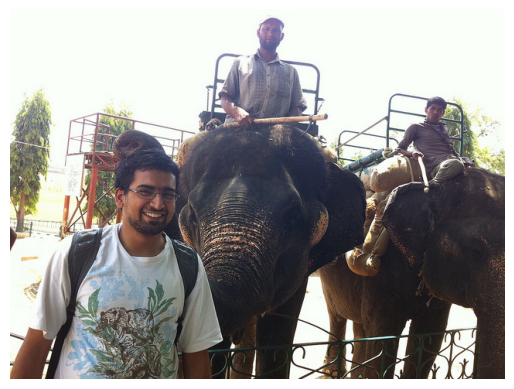

In [24]:
compare_dial_clip(207, dc.dict_dial_img_description, indx2lbl_coco, probs)

In [98]:
# list_descriptions = list(dc.dict_dial_img_description.values())
# og_dial_descr = list(chain.from_iterable(list_descriptions))
# og_dial_descr_tnsr = clip.tokenize(og_dial_descr).to(device)

In [99]:
# indx2lbl_og = {x:og_dial_descr[x] for x in range(len(og_dial_descr))}

In [100]:
# with torch.no_grad():
    
#     logits_per_image_og, logits_per_text_og = ViT32(list_tnsrs_imgs, list_classes_coco_tnsr)
#     probs_og = logits_per_image.softmax(dim=-1).cpu().numpy()
    

Human Dialogue:
0 - Stick the guy holding two elephants?
1 - White shirt in front of elephant walking?
2 - a man in a white shirt , in front of two elephants that are giving rides to two people
3 - man in white shirt , in front of two elephants giving rides
4 - man white shirt , in front of two riding elephants

Clip Object Detection:
0.9551 - Do you have 2 men, 1 holding a stop sign?
0.0075 - do you have a lady with a black umbrell, and cream dress. in from of car, umbrella is open
0.004 - do you have a two guys talking, there is a blue truck in the background. he is carrying a stop sign
0.0028 - Do you have the 2 men in front of a truck with the stop sign?
0.0024 - 2 guys, 1 with stop sign?


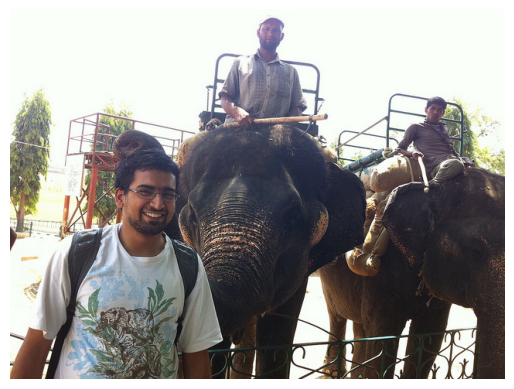

In [103]:
# compare_dial_clip(207, dc.dict_dial_img_description, indx2lbl_og, probs_og)

In [23]:
# with open('imagenet-classes.txt') as file:
#     readable = file.read()
#     splited = readable.split("\n")

#     list_classes_imagenet = []
#     for i, line in enumerate(splited):
#         match = re.match(r'^([^,]+)', line)
#         if match:
#             result = match.group(1)
#             list_classes_imagenet.append(result)
                        
# list_classes_imagenet_tnsr = clip.tokenize(list_classes_imagenet).to(device)


In [24]:
# indx2lbl_imagenet = {x:list_classes_imagenet[x] for x in range(len(list_classes_imagenet))}

In [25]:
# with torch.no_grad():
    
#     logits_per_image, logits_per_text = ViT32(list_tnsrs_imgs, list_classes_imagenet_tnsr)
#     probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    
# # print("Label probs:", probs)  # prints: [[0.9927937  0.00421068 0.00299572]]


In [26]:
# # this function is wrong, rn it only accepts integers as "title argument"
# def compare_dial_clip(title, main_dict, i2l):
#     list_of_keys = list(main_dict.keys())
#     if isinstance(title, int):
#         title_string = list_of_keys[title]
#     print("Human Dialogue:")
#     for i, descr in enumerate(main_dict[title_string]):
#         print(i, "-", descr)

#     photo = mpimg.imread("PhotoBook/images/" + title_string)

#     unordered_list = []
#     for i, value in enumerate(probs[title]):
#         label = i2l[i]
#         unordered_list.append((label, float(value)))
#     sorted_list = sorted(unordered_list, key=lambda tpl: tpl[1], reverse=True)

#     print("\nClip Object Detection:")
#     for tpl in sorted_list[:5]:
#         print(round(tpl[1], 4), "-", tpl[0])

#     plt.imshow(photo)
#     plt.axis("off")
# compare_dial_clip(207, dc.dict_dial_img_description, indx2lbl_imagenet)